<a href="https://colab.research.google.com/github/linarevheim-svg/NHS-Antibiotic-Prescribing-Trends-England/blob/main/Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
# ── 2. Load your data ────────────────────────────────────────────────
# Export your BigQuery results as CSV, then upload to Colab:
# Click the folder icon (left sidebar) → upload → select your file
df = pd.read_csv("prescribing_results.csv")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nSample:")
df.head()

Shape: (42, 6)

Columns: ['year', 'region_name', 'annual_items', 'annual_cost_gbp', 'national_avg_items', 'pct_above_national_avg']

Sample:


,year,region_name,annual_items,annual_cost_gbp,national_avg_items,pct_above_national_avg
0,2026,MIDLANDS COMMISSIONING REGION,1037388,5267911.12,749652.0,38.4
1,2026,NORTH EAST AND YORKSHIRE COMMISSIONING REGION,877154,4888201.17,749652.0,17.0
2,2026,SOUTH EAST COMMISSIONING REGION,779260,3827689.77,749652.0,3.9
3,2026,NORTH WEST COMMISSIONING REGION,700769,3688109.97,749652.0,-6.5
4,2026,EAST OF ENGLAND COMMISSIONING REGION,675740,3069885.12,749652.0,-9.9


In [ ]:
# ── 3. Clean & validate ──────────────────────────────────────────────

# Check for nulls
print("Nulls per column:")
print(df.isnull().sum())

# Check data types
print("\nData types:")
print(df.dtypes)

# Standardise column names (lowercase, no spaces)
df.columns = df.columns.str.lower().str.replace(" ", "_")

# Drop any rows missing region or year
df = df.dropna(subset=["region_name", "year"])

# Confirm years in range
print("\nYears present:", sorted(df["year"].unique()))
print("Regions present:", df["region_name"].nunique())

Nulls per column:
year                      0
region_name               0
annual_items              0
annual_cost_gbp           0
national_avg_items        0
pct_above_national_avg    0
dtype: int64

Data types:
year                        int64
region_name                object
annual_items                int64
annual_cost_gbp           float64
national_avg_items        float64
pct_above_national_avg    float64
dtype: object

Years present: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Regions present: 7


In [ ]:
# ── 4. Year-on-year change ───────────────────────────────────────────

pivot = df.pivot_table(
    index="region_name",
    columns="year",
    values="annual_items",
    aggfunc="sum"
)

pivot["pct_change_overall"] = (
    (pivot.iloc[:, -1] - pivot.iloc[:, 0]) / pivot.iloc[:, 0] * 100
).round(1)

print("Year-on-year change by region:")
print(pivot[["pct_change_overall"]].sort_values("pct_change_overall", ascending=False))

Year-on-year change by region:
year                                           pct_change_overall
region_name                                                      
LONDON COMMISSIONING REGION                                 -77.0
EAST OF ENGLAND COMMISSIONING REGION                        -77.2
SOUTH WEST COMMISSIONING REGION                             -77.4
SOUTH EAST COMMISSIONING REGION                             -77.8
MIDLANDS COMMISSIONING REGION                               -78.0
NORTH EAST AND YORKSHIRE COMMISSIONING REGION               -78.2
NORTH WEST COMMISSIONING REGION                             -79.2


In [ ]:
# ── 5. Outlier detection ─────────────────────────────────────────────

latest_year = df["year"].max()
latest = df[df["year"] == latest_year].copy()

mean = latest["annual_items"].mean()
std  = latest["annual_items"].std()

latest["z_score"] = ((latest["annual_items"] - mean) / std).round(2)
latest["outlier"]  = latest["z_score"] > 1

print(f"National average ({latest_year}): {mean:,.0f} items")
print(f"\nOutlier regions (>1 SD above average):")
print(
    latest[latest["outlier"]][["region_name", "annual_items", "z_score"]]
    .sort_values("z_score", ascending=False)
    .to_string(index=False)
)

National average (2026): 749,652 items

Outlier regions (>1 SD above average):
                  region_name  annual_items  z_score
MIDLANDS COMMISSIONING REGION       1037388     1.69


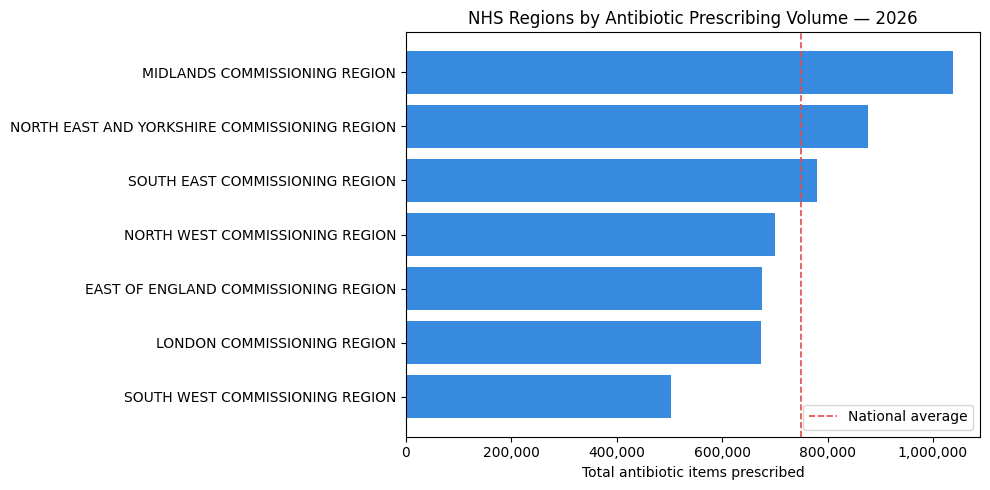

✓ Saved top_regions.png


In [ ]:
# ── 6. Chart 1 — top regions by prescribing volume ──────────────────

top_regions = (
    latest.sort_values("annual_items", ascending=False)
    .head(7)
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(top_regions["region_name"], top_regions["annual_items"], color="#378ADD")
ax.axvline(mean, color="#E24B4A", linestyle="--", linewidth=1.2, label="National average")

ax.set_xlabel("Total antibiotic items prescribed")
ax.set_title(f"NHS Regions by Antibiotic Prescribing Volume — {latest_year}")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.savefig("top_regions.png", dpi=150)
plt.show()
print("✓ Saved top_regions.png")

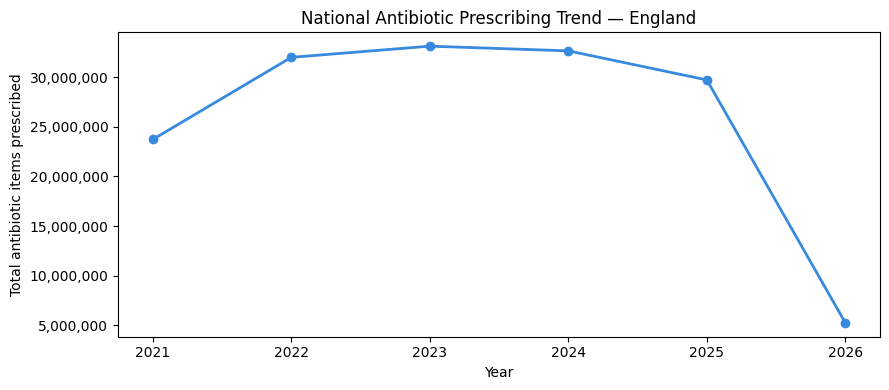

✓ Saved national_trend.png


In [ ]:
# ── 7. Chart 2 — national trend over time ────────────────────────────

national_trend = (
    df.groupby("year")["annual_items"]
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(
    national_trend["year"],
    national_trend["annual_items"],
    marker="o", linewidth=2, color="#378ADD"
)

ax.set_xlabel("Year")
ax.set_ylabel("Total antibiotic items prescribed")
ax.set_title("National Antibiotic Prescribing Trend — England")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_xticks(national_trend["year"])
plt.tight_layout()
plt.savefig("national_trend.png", dpi=150)
plt.show()
print("✓ Saved national_trend.png")

In [ ]:
# ── 8. Export clean data for Tableau ─────────────────────────────────

export = df[[
    "year", "region_name", "annual_items",
    "annual_cost_gbp", "national_avg_items", "pct_above_national_avg"
]].copy()

export.to_csv("prescribing_clean.csv", index=False)
print("✓ Saved prescribing_clean.csv — upload this to Tableau Public next")

✓ Saved prescribing_clean.csv — upload this to Tableau Public next


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
